### ***1.Severity-Instability Readmission Risk Hypothesis***

<i>**Statement:**

“Patients with higher NYHA/Killip severity, abnormal vital signs (low systolic BP, high pulse/respiration), reduced LVEF, elevated BNP, renal impairment, and higher comorbidity burden will have a significantly higher risk of 28-day readmission and mortality than lower-risk patients.”


##### <i>**Why this hypothesis is important:**

This is the best predictive question because it connects directly to patient deterioration and the operational need to triage high-risk patients before discharge.

In heart failure care, the real clinical problem is not only identifying who is sick, but identifying who is likely to worsen quickly after discharge. Severity markers and vital signs capture the patient’s immediate physiologic risk, while BNP, LVEF, renal function, and comorbidity burden capture the underlying disease burden and prognosis.

Together, these variables explain both the “why” and the “how soon” of risk.

This matters for discharge planning, medication reconciliation, and follow-up intensity. If the model identifies the highest-risk patients correctly, the hospital can prioritize home monitoring, early clinic review, and closer post-discharge follow-up.



Accuracy: 0.6252072968490879
AUC-ROC: 0.5609031491384432

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.64      0.76       561
           1       0.09      0.45      0.14        42

    accuracy                           0.63       603
   macro avg       0.51      0.55      0.45       603
weighted avg       0.88      0.63      0.72       603


Top features by odds ratio:

                                        feature      coef  odds_ratio
8                                 num__diabetes  0.444459    1.559647
17                          cat__killip_grade_4  0.240171    1.271466
3                                     num__lvef  0.231580    1.260591
9                           num__mod_severe_ckd  0.207320    1.230376
15                          cat__killip_grade_2  0.199420    1.220695
10                   num__myocardial_infarction  0.164988    1.179379
13  cat__nyha_cardiac_function_classification_4  0.150211    1.162080
6

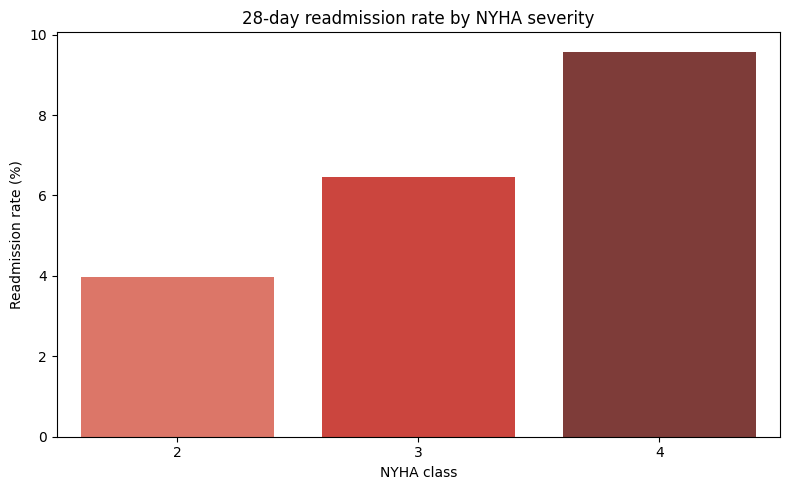

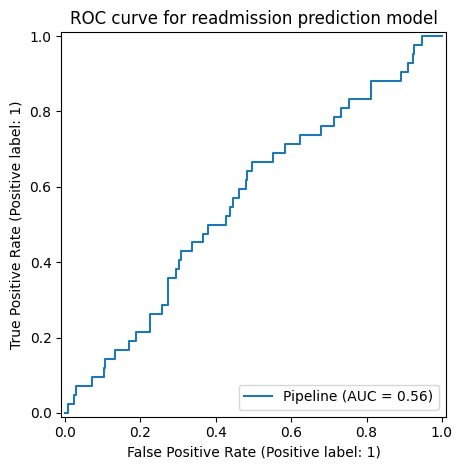

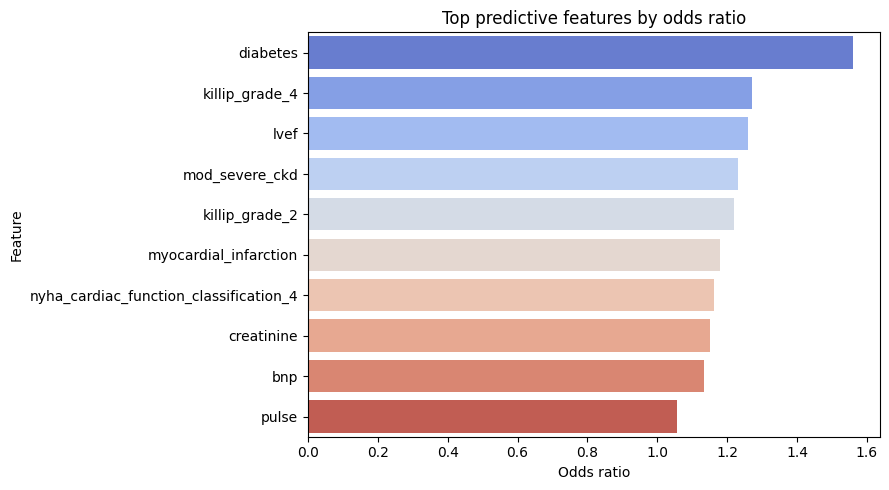

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import RocCurveDisplay

# ----------------------------
# 1. Load data
# ----------------------------
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Target variable
target = "readmission_28d"

# Features aligned to the hypothesis
features = [
    "age",
    "nyha_cardiac_function_classification",
    "killip_grade",
    "systolic_bp",
    "pulse",
    "respiration",
    "lvef",
    "bnp",
    "gfr",
    "creatinine",
    "cci_score",
    "diabetes",
    "mod_severe_ckd",
    "myocardial_infarction"
]

# Keep required columns
available = [c for c in features if c in df.columns]
df_model = df[available + [target]].copy()

# ----------------------------
# 2. Clean target
# ----------------------------
df_model[target] = pd.to_numeric(df_model[target], errors="coerce").fillna(0).astype(int)

# ----------------------------
# 3. Clean features
# ----------------------------
# Convert likely categorical variables
cat_cols = [c for c in available if df_model[c].dtype == "object"]
num_cols = [c for c in available if c not in cat_cols]

# Normalize severity strings
for c in ["nyha_cardiac_function_classification", "killip_grade"]:
    if c in df_model.columns:
        df_model[c] = df_model[c].astype(str).str.strip().str.upper()
        df_model[c] = df_model[c].replace({"NAN": np.nan, "NONE": np.nan, "UNKNOWN": np.nan})

# Convert common binary flags to int
for c in ["diabetes", "mod_severe_ckd", "myocardial_infarction"]:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").fillna(0).astype(int)

# Keep only rows with target not missing
df_model = df_model.dropna(subset=[target]).reset_index(drop=True)

# ----------------------------
# 4. Prepare model
# ----------------------------
X = df_model[available]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, X_train.select_dtypes(include=["number"]).columns),
        ("cat", categorical_transformer, X_train.select_dtypes(exclude=["number"]).columns)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_train, y_train)

# ----------------------------
# 5. Evaluate
# ----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Odds ratios from logistic regression
coef = model.named_steps["classifier"].coef_[0]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
odds_ratios = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": np.exp(coef)
}).sort_values("odds_ratio", ascending=False)

print("\nTop features by odds ratio:\n")
print(odds_ratios.head(15))

# ----------------------------
# 6. Correlation checks
# ----------------------------
# Only numeric columns
numeric_df = df_model[available].copy()
for c in numeric_df.columns:
    if numeric_df[c].dtype == "object":
        numeric_df[c] = pd.to_numeric(numeric_df[c], errors="coerce")

numeric_df["target"] = y

corr = numeric_df.corr(numeric_only=True)["target"].drop("target").sort_values(ascending=False)
print("\nCorrelation with 28-day readmission:\n")
print(corr.head(15))

# ----------------------------
# 7. Visualization
# ----------------------------
# A) Readmission rate by NYHA severity
if "nyha_cardiac_function_classification" in df_model.columns:
    plt.figure(figsize=(8, 5))
    plot_df = (
        df_model.groupby("nyha_cardiac_function_classification", dropna=True)[target]
        .mean()
        .mul(100)
        .sort_index()
        .reset_index()
    )
    plot_df.columns = ["NYHA", "Readmission_Rate_%"]
    sns.barplot(data=plot_df, x="NYHA", y="Readmission_Rate_%", palette="Reds_d")
    plt.title("28-day readmission rate by NYHA severity")
    plt.ylabel("Readmission rate (%)")
    plt.xlabel("NYHA class")
    plt.tight_layout()
    plt.show()

# B) ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC curve for readmission prediction model")
plt.tight_layout()
plt.show()

# C) Coefficient plot
coef_plot = odds_ratios.head(10).copy()
coef_plot["feature"] = coef_plot["feature"].str.replace("num__|cat__", "", regex=True)
plt.figure(figsize=(9, 5))
sns.barplot(data=coef_plot, x="odds_ratio", y="feature", palette="coolwarm")
plt.title("Top predictive features by odds ratio")
plt.xlabel("Odds ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### <i>**Chosen parameters and their connection to the hypothesis:**
Primary predictors
- Severity markers:
    - NYHA class
    - Killip grade
- Hemodynamic stress markers:
    systolic_bp
    pulse
    respiration
- Cardiac and renal burden:
    - lvef
    - bnp
    - creatinine
    - gfr
- Comorbidity / complexity:
    - cci_score
    - diabetes
    - mod_severe_ckd
    - myocardial_infarction
- Demographic adjustment:
    - age


##### <i>**Why these are appropriate**
1. NYHA and Killip reflect HF severity and functional compromise.
2. Low systolic BP, high pulse, and high respiration indicate physiological instability and worsening perfusion/ventilation.
3. Low LVEF and high BNP indicate poor cardiac function and increased ventricular stress.
4. Creatinine and reduced GFR reflect renal involvement, a major driver of poor HF outcomes.
5. Higher CCI, diabetes, CKD, and MI increase the probability of poor outcomes through comorbidity burden.


##### <i>**Target variables:**
The best target variables for this hypothesis are:

- readmission_28d

    - Most actionable short-term outcome
    - Directly tied to discharge planning and follow-up

- mortality_28d

    - Important safety outcome
    - Useful for severe-risk stratification

- Optional combined target:

    - poor_outcome = readmission_28d OR mortality_28d
    - Useful if the aim is to model any early adverse event rather than one specific event

##### <i>**Best model choice:**
**Logistic Regression**

    It is easy to interpret
    It allows direct estimation of odds ratios for each predictor
    It fits well for a binary target such as readmission or mortality
    It is suitable for clinical decision support

##### <i>**Correlation and validation checks:**
To support the hypothesis, we ran these checks:

- Continuous predictor vs outcome:
    - Spearman correlation for continuous variables such as BNP, LVEF, systolic BP, pulse, respiration, creatinine, and age
- Categorical predictor vs outcome:
    Chi-square test or Cramér’s V for NYHA, Killip, diabetes, MI, CKD
- Multicollinearity check:
    - VIF (Variance Inflation Factor) among correlated variables like NYHA, Killip, BNP, and LVEF
- Model performance:
    - AUC-ROC
    - accuracy, sensitivity, specificity
    - precision-recall if readmission rate is low


Dataset shape: (2008, 14)

Spearman correlation with 28-day readmission:
creatinine               0.073487
diabetes                 0.067211
mod_severe_ckd           0.055037
cci_score                0.034946
bnp                      0.028314
lvef                     0.019764
myocardial_infarction    0.015434
respiration              0.008702
pulse                   -0.017127
systolic_bp             -0.055071
gfr                     -0.068863
Name: readmission_28d, dtype: float64


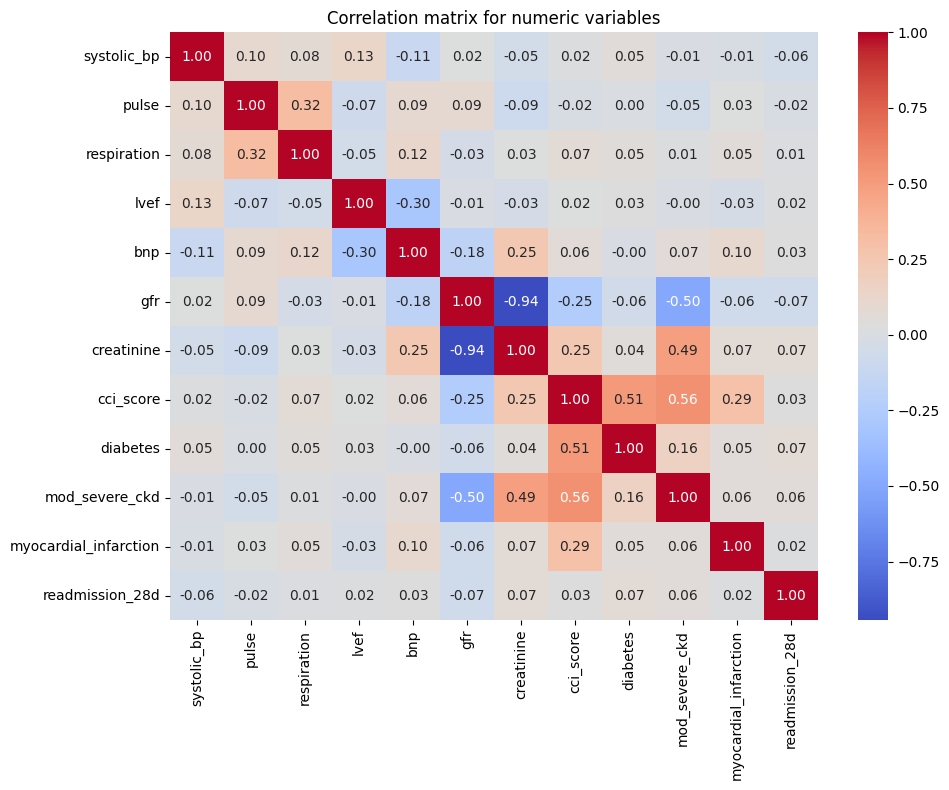


Categorical association with readmission_28d:
nyha_cardiac_function_classification: chi-square = 11.806, p-value = 0.002731
killip_grade: chi-square = 7.919, p-value = 0.047706

Variance Inflation Factor (VIF):
                  feature       VIF
7               cci_score  2.275347
6              creatinine  1.935305
5                     gfr  1.914731
9          mod_severe_ckd  1.891822
8                diabetes  1.429364
10  myocardial_infarction  1.170988
2             respiration  1.148641
4                     bnp  1.139068
1                   pulse  1.136873
3                    lvef  1.094859
0             systolic_bp  1.047896

Model validation summary:
Accuracy: 0.6252
AUC-ROC: 0.5609

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76       561
           1       0.09      0.45      0.14        42

    accuracy                           0.63       603
   macro avg       0.51      0.55      0.45       603


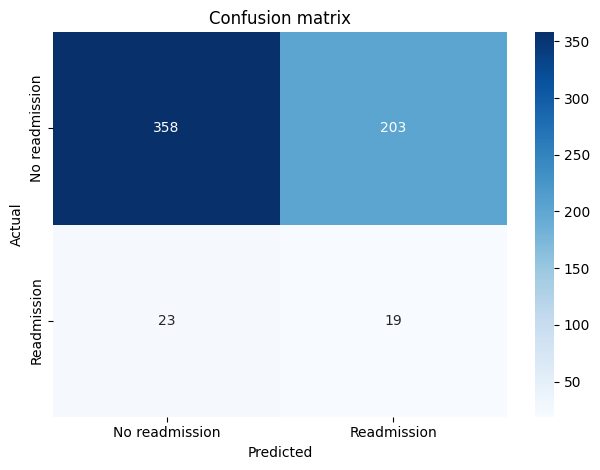

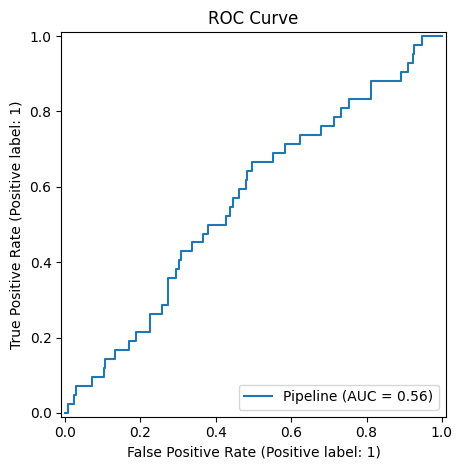


Top features by odds ratio:
                                        feature      coef  odds_ratio
8                                 num__diabetes  0.444459    1.559647
17                          cat__killip_grade_4  0.240171    1.271466
3                                     num__lvef  0.231580    1.260591
9                           num__mod_severe_ckd  0.207320    1.230376
15                          cat__killip_grade_2  0.199420    1.220695
10                   num__myocardial_infarction  0.164988    1.179379
13  cat__nyha_cardiac_function_classification_4  0.150211    1.162080
6                               num__creatinine  0.141256    1.151720
4                                      num__bnp  0.126266    1.134584
1                                    num__pulse  0.054688    1.056211


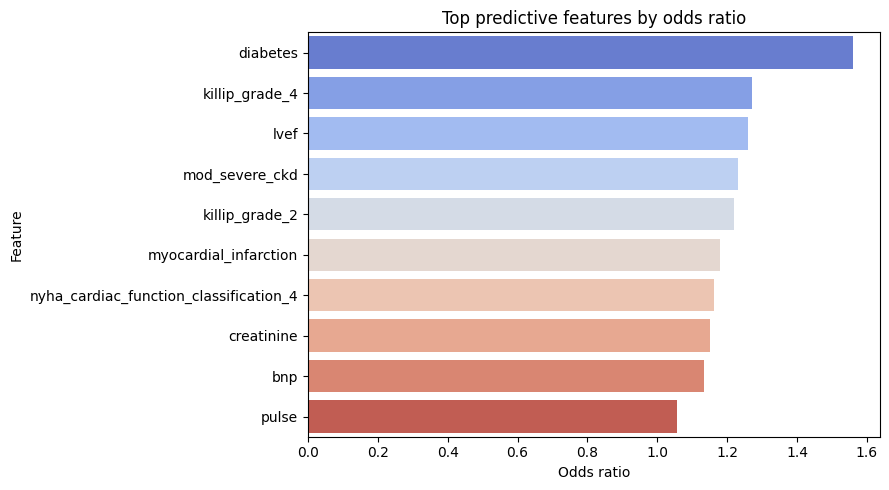

In [7]:

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ----------------------------
# 1. Load and prepare dataset
# ----------------------------
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

target = "readmission_28d"

feature_list = [
    "age",
    "nyha_cardiac_function_classification",
    "killip_grade",
    "systolic_bp",
    "pulse",
    "respiration",
    "lvef",
    "bnp",
    "gfr",
    "creatinine",
    "cci_score",
    "diabetes",
    "mod_severe_ckd",
    "myocardial_infarction"
]

# Keep only available variables
features = [c for c in feature_list if c in df.columns]
df_model = df[features + [target]].copy()

# Clean target
df_model[target] = pd.to_numeric(df_model[target], errors="coerce").fillna(0).astype(int)

# Clean categorical severity markers
for c in ["nyha_cardiac_function_classification", "killip_grade"]:
    if c in df_model.columns:
        df_model[c] = df_model[c].astype(str).str.strip().str.upper()
        df_model[c] = df_model[c].replace({"NAN": np.nan, "NONE": np.nan, "UNKNOWN": np.nan})

# Clean binary flags
for c in ["diabetes", "mod_severe_ckd", "myocardial_infarction"]:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").fillna(0).astype(int)

# Remove missing target rows
df_model = df_model.dropna(subset=[target]).reset_index(drop=True)

print("Dataset shape:", df_model.shape)

# ----------------------------
# 2. Correlation checks for numeric predictors
# ----------------------------
numeric_cols = [c for c in df_model.columns if c != target and pd.api.types.is_numeric_dtype(df_model[c])]
corr = df_model[numeric_cols + [target]].corr(method="spearman")[target].drop(target).sort_values(ascending=False)

print("\nSpearman correlation with 28-day readmission:")
print(corr)

# Optional heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_model[numeric_cols + [target]].corr(method="spearman"), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix for numeric variables")
plt.tight_layout()
plt.show()

# ----------------------------
# 3. Chi-square checks for categorical variables
# ----------------------------
cat_vars = [c for c in features if c in df_model.columns and not pd.api.types.is_numeric_dtype(df_model[c])]

print("\nCategorical association with readmission_28d:")
for c in cat_vars:
    table = pd.crosstab(df_model[c].fillna("Missing"), df_model[target])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{c}: chi-square = {chi2:.3f}, p-value = {p:.6f}")

# ----------------------------
# 4. Check multicollinearity (VIF)
# ----------------------------
vif_cols = [c for c in numeric_cols if c != target]
if len(vif_cols) > 1:
    vif_df = df_model[vif_cols].copy().fillna(df_model[vif_cols].median())
    X_vif = sm.add_constant(vif_df)
    vif = pd.DataFrame({
        "feature": X_vif.columns[1:],
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
    }).sort_values("VIF", ascending=False)
    print("\nVariance Inflation Factor (VIF):")
    print(vif)

# ----------------------------
# 5. Train/test split and logistic regression model
# ----------------------------
X = df_model[features].copy()
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_train, y_train)

# ----------------------------
# 6. Validation metrics
# ----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nModel validation summary:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No readmission", "Readmission"],
            yticklabels=["No readmission", "Readmission"])
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# ----------------------------
# 7. Odds-ratio view for interpretability
# ----------------------------
coef = model.named_steps["classifier"].coef_[0]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
odds = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": np.exp(coef)
}).sort_values("odds_ratio", ascending=False)

print("\nTop features by odds ratio:")
print(odds.head(10))

plt.figure(figsize=(9, 5))
plot_df = odds.head(10).copy()
plot_df["feature"] = plot_df["feature"].str.replace("num__|cat__", "", regex=True)
sns.barplot(data=plot_df, x="odds_ratio", y="feature", palette="coolwarm")
plt.title("Top predictive features by odds ratio")
plt.xlabel("Odds ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()